# FIN-RoBERTa vs FinBERT — Model Comparison

Side-by-side evaluation of **FIN-RoBERTa** (custom) and **FinBERT** (baseline) on the Financial PhraseBank dataset (sentences_allagree — 100% annotator agreement).

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load both models for comparison
models = {}
for name, hf_id in [("FIN-RoBERTa", "alasteirho/FIN-RoBERTa-Custom"), ("FinBERT", "ProsusAI/finbert")]:
    print(f"Loading {name}")
    tok = AutoTokenizer.from_pretrained(hf_id)
    mdl = AutoModelForSequenceClassification.from_pretrained(hf_id).to(device).eval()
    models[name] = {"tokenizer": tok, "model": mdl}
print("All models loaded.")

Device: cuda
Loading FIN-RoBERTa


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading FinBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All models loaded.


In [ ]:
# ======== Load dataset ========
dataset = load_dataset("takala/financial_phrasebank", "sentences_allagree")
df = pd.DataFrame(dataset["train"])
df["sentiment"] = df["label"].map({0: "negative", 1: "neutral", 2: "positive"})
print(f"Dataset: {len(df)} samples")
print(df["sentiment"].value_counts())

# ======== Label maps per model ========
LABEL_MAPS = {
    "FIN-RoBERTa": {0: "negative", 1: "neutral", 2: "positive"},
    "FinBERT":     {0: "positive", 1: "negative", 2: "neutral"},
}

# ======== Run predictions for both models ========
y_true = df["sentiment"].astype(str).str.lower()
all_preds = {}

for name, m in models.items():
    preds = []
    tok, mdl, lmap = m["tokenizer"], m["model"], LABEL_MAPS[name]
    for text in tqdm(df["sentence"], desc=name):
        inputs = tok(str(text), return_tensors="pt", truncation=True, max_length=512, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = mdl(**inputs).logits
        pred_idx = torch.argmax(logits, dim=-1).item()
        preds.append(lmap[pred_idx])
    all_preds[name] = preds
    print(f"{name} accuracy: {accuracy_score(y_true, preds):.4f}\n")

Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'sentences_allagree' at C:\Users\Alasteir\.cache\huggingface\datasets\takala___financial_phrasebank\sentences_allagree\0.0.0\0dd3028d70cbd18ded8887e65e83343b03a50482 (last modified on Tue Jan 27 01:23:32 2026).


Dataset: 2264 samples
sentiment
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


FIN-RoBERTa: 100%|██████████| 2264/2264 [00:12<00:00, 178.66it/s]


FIN-RoBERTa accuracy: 0.9929



FinBERT: 100%|██████████| 2264/2264 [00:11<00:00, 189.68it/s]

FinBERT accuracy: 0.9717



## Classification Reports

In [ ]:
labels = ["positive", "neutral", "negative"]

for name, preds in all_preds.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_true, preds, digits=3))


FIN-RoBERTa
              precision    recall  f1-score   support

    negative      0.987     0.993     0.990       303
     neutral      0.995     0.996     0.996      1391
    positive      0.991     0.984     0.988       570

    accuracy                          0.993      2264
   macro avg      0.991     0.991     0.991      2264
weighted avg      0.993     0.993     0.993      2264


FinBERT
              precision    recall  f1-score   support

    negative      0.906     0.983     0.943       303
     neutral      0.999     0.967     0.982      1391
    positive      0.947     0.977     0.962       570

    accuracy                          0.972      2264
   macro avg      0.951     0.976     0.963      2264
weighted avg      0.973     0.972     0.972      2264



## Metrics Comparison

             Accuracy  Macro F1  Macro Precision  Macro Recall
FIN-RoBERTa    0.9929    0.9912           0.9910        0.9913
FinBERT        0.9717    0.9625           0.9505        0.9759


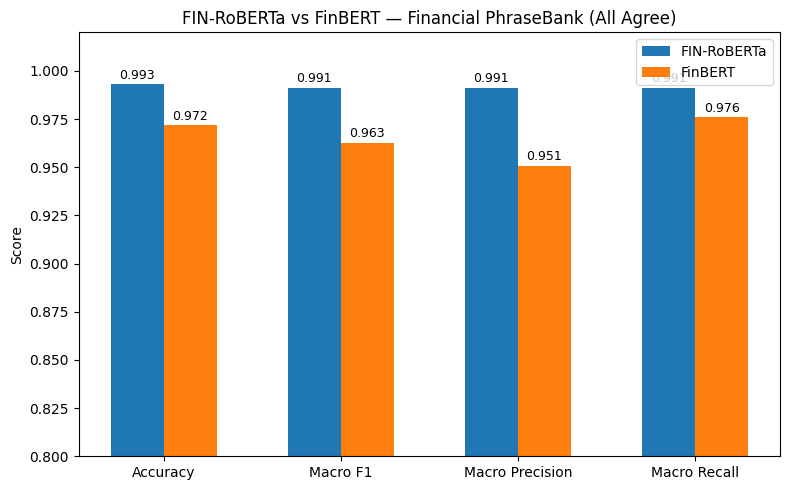

In [ ]:
# Comparison table 
metrics = {}
for name, preds in all_preds.items():
    metrics[name] = {
        "Accuracy": accuracy_score(y_true, preds),
        "Macro F1": f1_score(y_true, preds, average="macro"),
        "Macro Precision": precision_score(y_true, preds, average="macro"),
        "Macro Recall": recall_score(y_true, preds, average="macro"),
    }

comparison_df = pd.DataFrame(metrics).T
print(comparison_df.to_string(float_format=lambda x: f"{x:.4f}"))

# Bar chart 
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison_df.columns))
width = 0.3

for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=model_name)
    for j, v in enumerate(row.values):
        ax.text(x[j] + i * width, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)

ax.set_ylabel("Score")
ax.set_title("FIN-RoBERTa vs FinBERT — Financial PhraseBank (All Agree)")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(comparison_df.columns)
ax.set_ylim(0.8, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

## Confusion Matrices

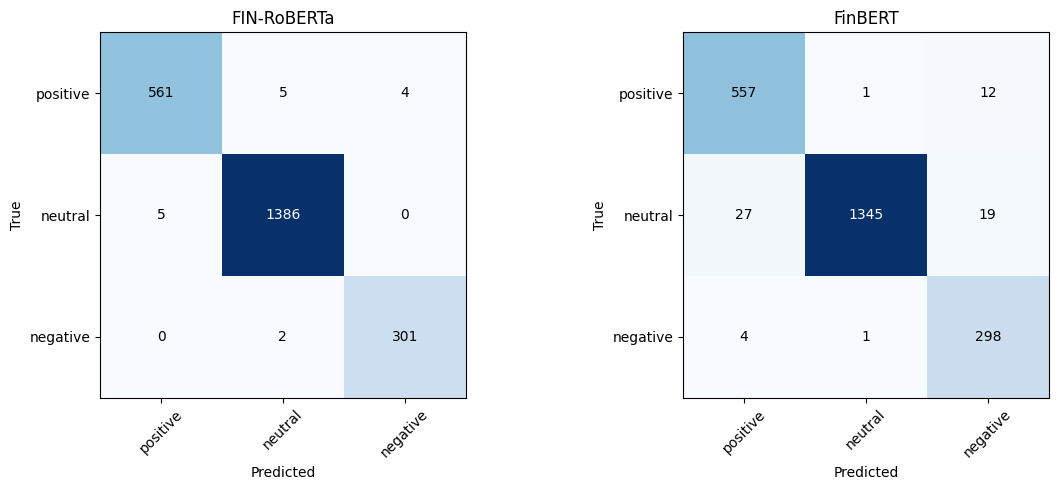

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_true, preds, labels=labels)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(name)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()